Inseption-LSTM Model (CNN + RNN with Handcrafted Features)
---

Imports
---

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Flatten, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import InceptionV3
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Definitions
---

In [2]:
# Load and preprocess images
def load_images(image_paths):
    images = []
    for path in image_paths:
        img = tf.keras.preprocessing.image.load_img(path, target_size=image_size)
        img = tf.keras.preprocessing.image.img_to_array(img)
        img = tf.keras.applications.inception_v3.preprocess_input(img)
        images.append(img)
    return np.array(images)

Process
---

In [3]:
# Load handcrafted features
data = pd.read_csv("../Dataset/Features/signature_features.csv")
labels = data["label"].values
handcrafted_features = data.iloc[:, 2:].values  # Skip filename and label columns

In [4]:
# Load images for CNN
image_size = (299, 299)  # InceptionV3 default input size
image_paths = [f"../Dataset/Processing/AugmentedDataset/{'Genuine' if label == 0 else 'Forged'}/{file}" for file, label in zip(data["filename"], labels)]

In [5]:
# Load images
images = load_images(image_paths)

# Split dataset
X_train_img, X_test_img, X_train_handcrafted, X_test_handcrafted, y_train, y_test = train_test_split(
    images, handcrafted_features, labels, test_size=0.2, random_state=42, stratify=labels)

In [6]:
# CNN Feature Extractor (InceptionV3)
inception_base = InceptionV3(weights=None, include_top=False, input_shape=(299, 299, 3))
cnn_output = GlobalAveragePooling2D()(inception_base.output)

# LSTM for sequence modeling
lstm_input = Input(shape=(X_train_handcrafted.shape[1], 1))  # Handcrafted features
lstm_layer = LSTM(128, return_sequences=False)(lstm_input)

# Combine CNN and LSTM
merged = Concatenate()([cnn_output, lstm_layer])
dense_layer = Dense(128, activation='relu')(merged)
dropout_layer = Dropout(0.5)(dense_layer)
output_layer = Dense(1, activation='sigmoid')(dropout_layer)

# Define hybrid model
model = Model(inputs=[inception_base.input, lstm_input], outputs=output_layer)

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
# Train model
model.fit(
    [X_train_img, X_train_handcrafted.reshape(-1, X_train_handcrafted.shape[1], 1)], y_train,
    validation_data=([X_test_img, X_test_handcrafted.reshape(-1, X_test_handcrafted.shape[1], 1)], y_test),
    epochs=25, batch_size=32)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 910s 2s/step - accuracy: 0.6254 - loss: 0.6941 - val_accuracy: 0.5774 - val_loss: 8.0247
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 856s 2s/step - accuracy: 0.7134 - loss: 0.4913 - val_accuracy: 0.6442 - val_loss: 9.9219
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 847s 2s/step - accuracy: 0.7677 - loss: 0.4293 - val_accuracy: 0.5422 - val_loss: 2.4609
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 843s 2s/step - accuracy: 0.8153 - loss: 0.3739 - val_accuracy: 0.5358 - val_loss: 5.2944
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 841s 2s/step - accuracy: 0.8222 - loss: 0.3721 - val_accuracy: 0.5195 - val_loss: 5.5156
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 836s 2s/step - accuracy: 0.8480 - loss: 0.3365 - val_accuracy: 0.6272 - val_loss: 1.7052
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 841s 2s/step - accuracy: 0.8759 - loss: 0.2886 - val_accuracy: 0.5099 - val_loss: 7.7241
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 846s 2s/step - accuracy: 0.8964 - loss: 0.2509 - val_accu

In [8]:
# Save model
model.save("../Model/signature_forgery_detection_model.h5")

print("Model training completed and saved!")

Model training completed and saved!


[ Optional: For Testing Purposes ] Load Model

In [9]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("../Model/signature_forgery_detection_model.h5")

Evaluation
---

In [10]:

# Predict on test set
y_pred_probs = model.predict([X_test_img, X_test_handcrafted.reshape(-1, X_test_handcrafted.shape[1], 1)])
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)


98/98 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step
Accuracy: 0.9706
Precision: 0.9646
Recall: 0.9770
F1-score: 0.9708
Confusion Matrix:
[[1508   56]
 [  36 1528]]


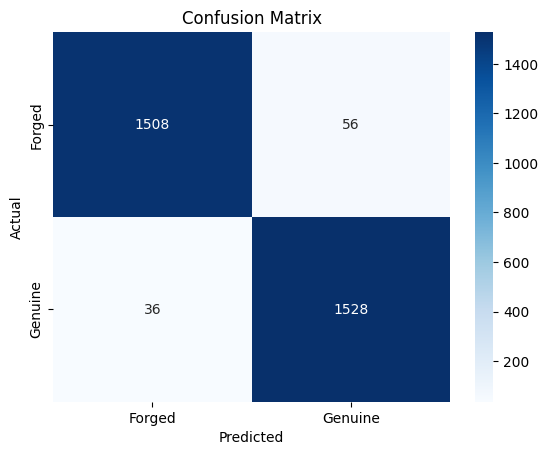

In [11]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()